# Decision Tree — baseline

| | |
|---|---|
| Đầu vào | `data/processed/train_sub.csv`, `val_set.csv` |
| Đơn vị dự báo | `(Store, Date)` — doanh số tuần của cả cửa hàng |
| Train | 4.275 dòng · 95 tuần · 2010-02-05 → 2011-11-25 |
| Val | 2.160 dòng · 48 tuần · 2011-12-02 → 2012-10-26 |
| Metric | WMAPE (chính), R², RMSE, MAE — không đặt trọng số cho tuần lễ |
| Tinh chỉnh | GridSearchCV + TimeSeriesSplit trên train; val không tham gia |

Luồng: xử lý dữ liệu → phân tích → mã hoá → xây mô hình → đánh giá → trực quan hoá.

## 0. Thiết lập

In [1]:
import sys
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

from sklearn.tree import DecisionTreeRegressor, plot_tree, export_text
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

%matplotlib inline


def find_processed_dir():
    """Dò ngược cây thư mục tìm data/processed — nơi preprocessing.ipynb ghi ra."""
    for folder in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
        candidate = folder / "data" / "processed"
        if (candidate / "train_sub.csv").exists():
            return candidate.resolve()
    raise FileNotFoundError("Chưa có data/processed/train_sub.csv — chạy preprocessing.ipynb trước.")


PROCESSED_DIR = find_processed_dir()
TARGET = "Weekly_Sales"
RANDOM_STATE = 42

# Bộ chỉ số dùng chung. Không đặt trọng số cho tuần lễ nên WMAE thu về đúng MAE,
# vì vậy chỉ báo cáo MAE.
METRIC_SHOW = ["wmape", "r2", "rmse", "mae"]


def wmape(y_true, y_pred):
    """Tổng sai số tuyệt đối chia tổng doanh số thật. Không thứ nguyên, so được giữa các quy mô."""
    y_true, y_pred = np.asarray(y_true, float), np.asarray(y_pred, float)
    return float(np.abs(y_true - y_pred).sum() / np.abs(y_true).sum())


def evaluate(y_true, y_pred) -> dict:
    """Bộ chỉ số dùng cho mọi bảng trong notebook."""
    y_true, y_pred = np.asarray(y_true, float), np.asarray(y_pred, float)
    return {
        "wmape": round(wmape(y_true, y_pred), 4),
        "r2": round(r2_score(y_true, y_pred), 4),
        "rmse": round(float(np.sqrt(mean_squared_error(y_true, y_pred))), 1),
        "mae": round(float(mean_absolute_error(y_true, y_pred)), 1),
    }


sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (11, 5)
plt.rcParams["figure.dpi"] = 100
plt.rcParams["axes.titleweight"] = "bold"

THEME = {"blue": "#0071CE", "blue_dark": "#004C91", "yellow": "#FFC220",
         "gray": "#6B7280", "gray_dark": "#374151",
         "danger": "#E76F51", "success": "#2A9D8F"}


def money(x, pos=None):
    if pd.isna(x):
        return "-"
    if abs(x) >= 1e6:
        return f"${x/1e6:.1f}M"
    if abs(x) >= 1e3:
        return f"${x/1e3:.0f}K"
    return f"${x:,.0f}"


MONEY_FMT = mtick.FuncFormatter(money)


def set_chart_title(ax, title, subtitle=None):
    ax.set_title(title, loc="left", color="#0F172A", pad=24, fontweight="bold")
    if subtitle:
        ax.text(0, 1.02, subtitle, transform=ax.transAxes, ha="left", va="bottom",
                fontsize=8.8, color=THEME["gray"])


def clean_axis(ax, xlabel, ylabel, xgrid=False):
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    ax.set_xlabel(xlabel, color=THEME["gray_dark"], labelpad=8)
    ax.set_ylabel(ylabel, color=THEME["gray_dark"], labelpad=8)
    ax.grid(True, axis="x" if xgrid else "y", linestyle="--", linewidth=0.7, alpha=0.35)
    ax.grid(False, axis="y" if xgrid else "x")


def label_bars(ax, container, fmt):
    """Ghi giá trị ở đầu mỗi thanh — đọc số không cần dóng theo lưới."""
    ax.bar_label(container, labels=[fmt(v) for v in container.datavalues],
                 padding=4, fontsize=8.5, color=THEME["gray_dark"])


print(f"processed : {PROCESSED_DIR}")

processed : D:\my_AI_my_learn\AIO_Conquer_Module3_PorscheClub\data\processed


## 1. Xử lý dữ liệu

Đọc 2 file `preprocessing.ipynb` đã ghi ra, sắp theo `Date`, rồi `assert` ranh giới thời gian
`train.Date.max() < val.Date.min()` — sai ở đây là leakage.

In [2]:
train_sub = pd.read_csv(PROCESSED_DIR / "train_sub.csv", parse_dates=["Date"])
val_set = pd.read_csv(PROCESSED_DIR / "val_set.csv", parse_dates=["Date"])

train_sub = train_sub.sort_values(["Date", "Store"]).reset_index(drop=True)
val_set = val_set.sort_values(["Date", "Store"]).reset_index(drop=True)
assert train_sub["Date"].max() < val_set["Date"].min(), "train và val chồng lấn thời gian!"

qc = pd.DataFrame({
    "Metric": ["Rows", "N Stores", "N Weeks", "Start Date", "End Date",
               "N Holiday Weeks", "Total Sales", "NaN cells"],
    "train_sub": [
        f"{len(train_sub):,}", train_sub["Store"].nunique(), train_sub["Date"].nunique(),
        f"{train_sub['Date'].min():%Y-%m-%d}", f"{train_sub['Date'].max():%Y-%m-%d}",
        train_sub.loc[train_sub["IsHoliday"] == 1, "Date"].nunique(),
        money(train_sub["Weekly_Sales"].sum()), f"{int(train_sub.isna().sum().sum()):,}",
    ],
    "val_set": [
        f"{len(val_set):,}", val_set["Store"].nunique(), val_set["Date"].nunique(),
        f"{val_set['Date'].min():%Y-%m-%d}", f"{val_set['Date'].max():%Y-%m-%d}",
        val_set.loc[val_set["IsHoliday"] == 1, "Date"].nunique(),
        money(val_set["Weekly_Sales"].sum()), f"{int(val_set.isna().sum().sum()):,}",
    ],
})
print(f"Tỉ lệ train/val: {len(train_sub)/(len(train_sub)+len(val_set)):.1%} / "
      f"{len(val_set)/(len(train_sub)+len(val_set)):.1%}\n")
qc

Tỉ lệ train/val: 66.4% / 33.6%



,Metric,train_sub,val_set
0,Rows,"4,275","2,160"
1,N Stores,45,45
2,N Weeks,95,48
3,Start Date,2010-02-05,2011-12-02
4,End Date,2011-11-25,2012-10-26
5,N Holiday Weeks,7,3
6,Total Sales,$4449.0M,$2288.2M
7,NaN cells,"3,285",0


## 2. Phân tích

Đo trên `train_sub` — `val_set` để dành chấm điểm, không nhìn vào trước khi dựng mô hình.

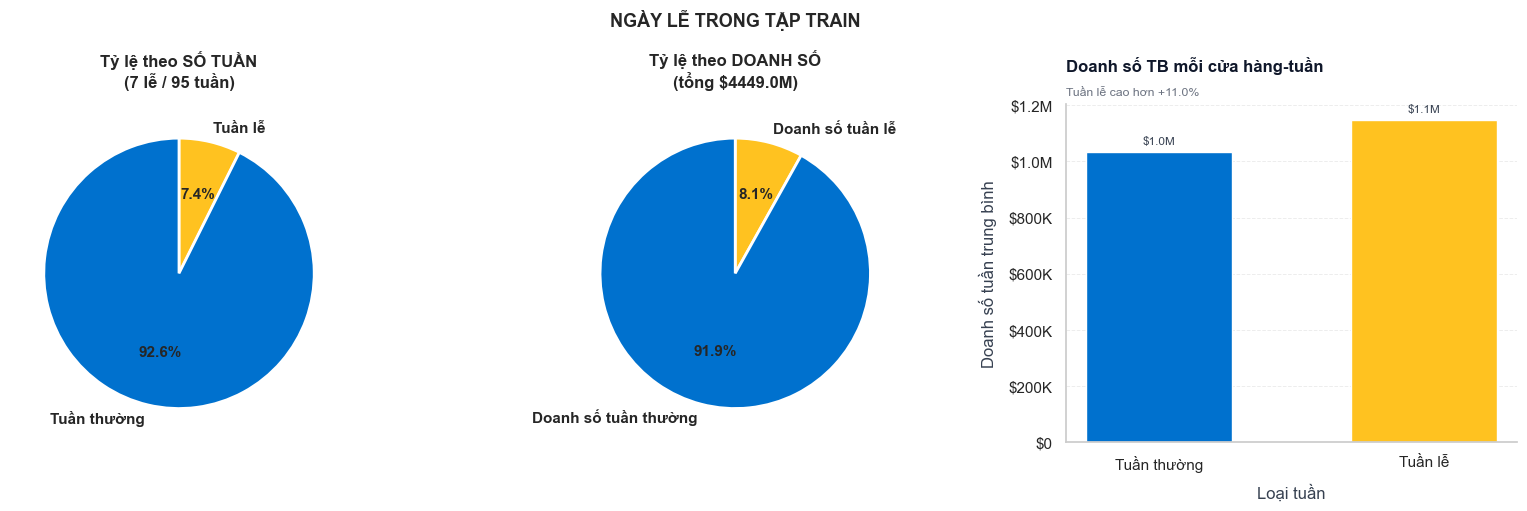

,Metric,Value
0,N Holiday Weeks,7
1,N Normal Weeks,88
2,Total Weeks,95
3,Holiday Weeks Share (%),7.4%
4,Holiday Sales Share (%),8.1%
5,Sales Share / Weeks Share,1.10x
6,Holiday Uplift (%),+11.0%


In [3]:
eda = train_sub          # EDA đo trên train, val để dành chấm điểm

n_weeks_hol = eda.loc[eda["IsHoliday"] == 1, "Date"].nunique()
n_weeks_all = eda["Date"].nunique()
n_weeks_nor = n_weeks_all - n_weeks_hol

sales_hol = eda.loc[eda["IsHoliday"] == 1, "Weekly_Sales"].sum()
sales_all = eda["Weekly_Sales"].sum()
sales_nor = sales_all - sales_hol

avg_hol = eda.loc[eda["IsHoliday"] == 1, "Weekly_Sales"].mean()
avg_nor = eda.loc[eda["IsHoliday"] == 0, "Weekly_Sales"].mean()

fig, axes = plt.subplots(1, 3, figsize=(16, 5.2))
pie_kw = dict(colors=[THEME["yellow"], THEME["blue"]], autopct="%1.1f%%",
              startangle=90, counterclock=False,
              textprops={"fontsize": 11, "fontweight": "bold"},
              wedgeprops={"edgecolor": "white", "linewidth": 2})

axes[0].pie([n_weeks_hol, n_weeks_nor], labels=["Tuần lễ", "Tuần thường"], **pie_kw)
axes[0].set_title(f"Tỷ lệ theo SỐ TUẦN\n({n_weeks_hol} lễ / {n_weeks_all} tuần)",
                  pad=12, fontweight="bold")

axes[1].pie([sales_hol, sales_nor], labels=["Doanh số tuần lễ", "Doanh số tuần thường"], **pie_kw)
axes[1].set_title(f"Tỷ lệ theo DOANH SỐ\n(tổng {money(sales_all)})", pad=12, fontweight="bold")

bars = axes[2].bar(["Tuần thường", "Tuần lễ"], [avg_nor, avg_hol],
                   color=[THEME["blue"], THEME["yellow"]], width=0.55)
label_bars(axes[2], bars, money)
axes[2].yaxis.set_major_formatter(MONEY_FMT)
set_chart_title(axes[2], "Doanh số TB mỗi cửa hàng-tuần",
                f"Tuần lễ cao hơn {(avg_hol/avg_nor - 1)*100:+.1f}%")
clean_axis(axes[2], "Loại tuần", "Doanh số tuần trung bình")

fig.suptitle("NGÀY LỄ TRONG TẬP TRAIN", fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()

pct_w, pct_s = n_weeks_hol / n_weeks_all * 100, sales_hol / sales_all * 100
pd.DataFrame({
    "Metric": ["N Holiday Weeks", "N Normal Weeks", "Total Weeks",
               "Holiday Weeks Share (%)", "Holiday Sales Share (%)",
               "Sales Share / Weeks Share", "Holiday Uplift (%)"],
    "Value": [n_weeks_hol, n_weeks_nor, n_weeks_all,
              f"{pct_w:.1f}%", f"{pct_s:.1f}%", f"{pct_s/pct_w:.2f}x",
              f"{(avg_hol/avg_nor - 1)*100:+.1f}%"],
})

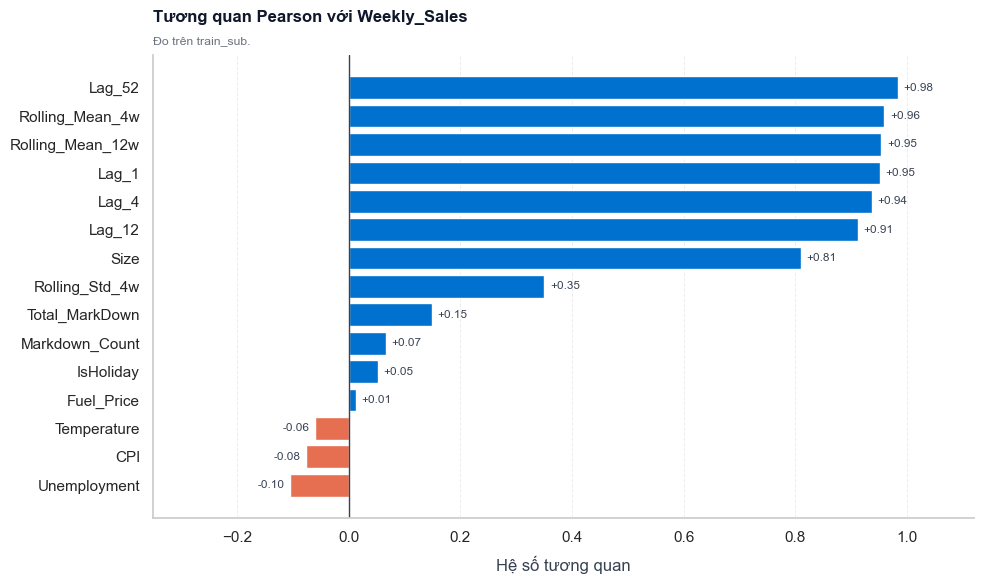

,Corr_with_Weekly_Sales
Lag_52,0.984
Rolling_Mean_4w,0.960
Rolling_Mean_12w,0.954
Lag_1,0.951
Lag_4,0.937
Lag_12,0.912
Size,0.809
Rolling_Std_4w,0.350
Total_MarkDown,0.149
Markdown_Count,0.066


In [4]:
corr_cols = (["Lag_1", "Lag_4", "Lag_12", "Lag_52"]
             + ["Rolling_Mean_4w", "Rolling_Mean_12w", "Rolling_Std_4w"]
             + ["Size", "Temperature", "Fuel_Price", "CPI", "Unemployment"]
             + ["Markdown_Count", "Total_MarkDown", "IsHoliday"])
corr = (train_sub[corr_cols].corrwith(train_sub["Weekly_Sales"])
        .sort_values().rename("Corr_with_Weekly_Sales"))

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(corr.index, corr.values,
               color=[THEME["blue"] if v >= 0 else THEME["danger"] for v in corr.values])
label_bars(ax, bars, lambda v: f"{v:+.2f}")
ax.axvline(0, color=THEME["gray_dark"], lw=1)
ax.set_xlim(-0.35, 1.12)
set_chart_title(ax, "Tương quan Pearson với Weekly_Sales", "Đo trên train_sub.")
clean_axis(ax, "Hệ số tương quan", "", xgrid=True)
fig.tight_layout()
plt.show()

corr.sort_values(ascending=False).round(3).to_frame()

## 3. Mã hoá đặc trưng

| Nhóm | Cột | Xử lý |
|---|---|---|
| Cửa hàng | `Store` | target encoding → `Store_te` |
| Loại cửa hàng | `Type` | ordinal `C=1 < B=2 < A=3` → `Type_ord` |
| Lịch | `Year`, `Month`, `Quarter`, `WeekOfYear`, `IsHoliday` | giữ dạng số |
| Số | `Size`, macro, `Lag_1/4/12/52`, `Rolling_*`, MarkDown | giữ nguyên |

`Type` có thứ tự A > B > C theo quy mô cửa hàng (Kaggle mô tả vậy, và dữ liệu xác nhận:
Size trung vị 202.406 / 114.533 / 39.910) nên mã hoá ordinal 1 cột thay vì one-hot 3 cột.

Nền chung 25 cột: 5 lịch + 19 số + `Type_ord`. Ba cách xử lý `Store` cho ra 3 kích cỡ:

| store_encoding | `Store` thành gì | Cột thêm | Tổng |
|---|---|---:|---:|
| `onehot` | 45 cột 0/1 — `Store_1` … `Store_45` | +45 | **70** |
| `target` | 1 cột `Store_te` — doanh số TB của cửa hàng đó, tính trên train | +1 | **26** |
| `none` | bỏ hẳn | +0 | **25** |

Target encoding thay số hiệu cửa hàng bằng một con số có nghĩa, để cây tách bằng một ngưỡng
thay vì 45 câu hỏi có/không. Bảng tra fit trên train rồi map sang val.

Không chuẩn hoá — cây so ngưỡng trong từng cột. Giữ `NaN` — `DecisionTreeRegressor`
(sklearn ≥ 1.4) tự định tuyến `NaN` sang nhánh giảm sai số nhiều hơn.

In [5]:
print("Store_te = doanh số TB mỗi cửa hàng, tính trên train:")
display(train_sub.groupby("Store")["Weekly_Sales"].mean()
        .round(0).rename("Store_te").head(5).to_frame())

TYPE_ORDER = {"C": 1, "B": 2, "A": 3}      # Kaggle: A > B > C theo quy mô cửa hàng
ORDINAL_COLS = ["Year", "Month", "Quarter", "WeekOfYear", "IsHoliday"]
NUMERIC_COLS = (["Size", "Temperature", "Fuel_Price", "CPI", "Unemployment"]
                + ["Lag_1", "Lag_4", "Lag_12", "Lag_52"]
                + ["Rolling_Mean_4w", "Rolling_Mean_12w", "Rolling_Std_4w"]
                + [f"Has_MarkDown_{i}" for i in range(1, 6)]
                + ["Markdown_Count", "Total_MarkDown"])


def build_feature_matrix(train, val, store_encoding="target"):
    """Dựng X_train / X_val. Mọi bảng tra đều fit trên train rồi mới áp sang val."""
    X_train = train[ORDINAL_COLS + NUMERIC_COLS].copy()
    X_val = val[ORDINAL_COLS + NUMERIC_COLS].copy()

    # Type có thứ tự A > B > C (Kaggle) -> ordinal encoding, 1 cột
    X_train["Type_ord"] = train["Type"].map(TYPE_ORDER).values
    X_val["Type_ord"] = val["Type"].map(TYPE_ORDER).values

    if store_encoding == "onehot":
        d_train = pd.get_dummies(train["Store"], prefix="Store", dtype=int)
        d_val = pd.get_dummies(val["Store"], prefix="Store", dtype=int).reindex(
            columns=d_train.columns, fill_value=0)
        X_train = pd.concat([X_train, d_train], axis=1)
        X_val = pd.concat([X_val, d_val], axis=1)
    elif store_encoding == "target":
        store_te = train.groupby("Store")[TARGET].mean()
        X_train["Store_te"] = train["Store"].map(store_te).values
        X_val["Store_te"] = val["Store"].map(store_te).fillna(train[TARGET].mean()).values

    assert list(X_train.columns) == list(X_val.columns), "X_train và X_val lệch cột!"
    return X_train, X_val, train[TARGET].to_numpy(), val[TARGET].to_numpy()


abl_rows = []
for enc in ["onehot", "target", "none"]:
    Xt, Xv, yt, yv = build_feature_matrix(train_sub, val_set, store_encoding=enc)
    mdl = DecisionTreeRegressor(max_depth=8, min_samples_leaf=5, random_state=RANDOM_STATE)
    mdl.fit(Xt, yt)
    abl_rows.append({"store_encoding": enc, "n_features": Xt.shape[1],
                     **evaluate(yv, mdl.predict(Xv))})

ablation_tbl = pd.DataFrame(abl_rows).set_index("store_encoding")
ablation_tbl["vs_onehot_wmape"] = (
    (ablation_tbl["wmape"] / ablation_tbl.loc["onehot", "wmape"] - 1) * 100
).round(1).astype(str) + "%"
ablation_tbl[["n_features", *METRIC_SHOW, "vs_onehot_wmape"]]

Store_te = doanh số TB mỗi cửa hàng, tính trên train:


,Store_te
Store,
1,1528086.0
2,1916936.0
3,391037.0
4,2038189.0
5,309216.0


,n_features,wmape,r2,rmse,mae,vs_onehot_wmape
store_encoding,,,,,,
onehot,70,0.0637,0.9622,110503.6,67437.7,0.0%
target,26,0.0634,0.9592,114763.2,67138.1,-0.5%
none,25,0.0637,0.9623,110275.2,67474.8,0.0%


In [6]:
STORE_ENCODING = "target"
X_train, X_val, y_train, y_val = build_feature_matrix(
    train_sub, val_set, store_encoding=STORE_ENCODING)

groups = {
    "Cửa hàng": ["Store_te", "Size"],
    "Loại cửa hàng": ["Type_ord"],
    "Lịch (giữ số)": ORDINAL_COLS,
    "Lag": [c for c in X_train.columns if c.startswith("Lag_")],
    "Rolling": [c for c in X_train.columns if c.startswith("Rolling_")],
    "Vĩ mô": ["Temperature", "Fuel_Price", "CPI", "Unemployment"],
    "Khuyến mãi": [c for c in X_train.columns
                   if c.startswith("Has_MarkDown") or c in ("Markdown_Count", "Total_MarkDown")],
}
assert sum(len(v) for v in groups.values()) == X_train.shape[1], "Bảng nhóm cột không khớp X_train!"

print(f"X_train: {X_train.shape[0]:,} dòng × {X_train.shape[1]} cột "
      f"(store_encoding = {STORE_ENCODING!r})")
display(pd.DataFrame([
    {"Nhóm": g, "Số cột": len(cols),
     "Cột": ", ".join(cols[:4]) + (" ..." if len(cols) > 4 else "")}
    for g, cols in groups.items()
]))
X_train.head()

X_train: 4,275 dòng × 26 cột (store_encoding = 'target')


,Nhóm,Số cột,Cột
0,Cửa hàng,2,"Store_te, Size"
1,Loại cửa hàng,1,Type_ord
2,Lịch (giữ số),5,"Year, Month, Quarter, WeekOfYear ..."
3,Lag,4,"Lag_1, Lag_4, Lag_12, Lag_52"
4,Rolling,3,"Rolling_Mean_4w, Rolling_Mean_12w, Rolling_Std_4w"
5,Vĩ mô,4,"Temperature, Fuel_Price, CPI, Unemployment"
6,Khuyến mãi,7,"Has_MarkDown_1, Has_MarkDown_2, Has_MarkDown_3..."


,Year,Month,Quarter,WeekOfYear,IsHoliday,Size,Temperature,Fuel_Price,CPI,Unemployment,...,Rolling_Std_4w,Has_MarkDown_1,Has_MarkDown_2,Has_MarkDown_3,Has_MarkDown_4,Has_MarkDown_5,Markdown_Count,Total_MarkDown,Type_ord,Store_te
0,2010,2,1,5,0,151315,42.31,2.572,211.096358,8.106,...,NaN,0,0,0,0,0,0,0.0,3,1.528086e+06
1,2010,2,1,5,0,202307,40.19,2.572,210.752605,8.324,...,NaN,0,0,0,0,0,0,0.0,3,1.916936e+06
2,2010,2,1,5,0,37392,45.71,2.572,214.424881,7.368,...,NaN,0,0,0,0,0,0,0.0,2,3.910367e+05
3,2010,2,1,5,0,205863,43.76,2.598,126.442065,8.623,...,NaN,0,0,0,0,0,0,0.0,3,2.038189e+06
4,2010,2,1,5,0,34875,39.70,2.572,211.653972,6.566,...,NaN,0,0,0,0,0,0,0.0,2,3.092155e+05


## 4. Xây mô hình

Cây mặc định làm mốc chưa tinh chỉnh, rồi `GridSearchCV` dò `max_depth` / `min_samples_leaf` /
`criterion` bằng `TimeSeriesSplit(4)`. Điểm chọn model là `MAE`, không phải MSE mặc định.

In [7]:
dt_default = DecisionTreeRegressor(random_state=RANDOM_STATE)
dt_default.fit(X_train, y_train)
pred_default = dt_default.predict(X_val)
m_default = evaluate(y_val, pred_default)

print(f"Cây mặc định: độ sâu {dt_default.get_depth()}, "
      f"{dt_default.get_n_leaves()} lá / {len(X_train):,} dòng train")
pd.DataFrame([m_default], index=["Decision Tree (mặc định)"])[METRIC_SHOW]

Cây mặc định: độ sâu 30, 4275 lá / 4,275 dòng train


,wmape,r2,rmse,mae
Decision Tree (mặc định),0.0698,0.9518,124714.7,73990.6


In [8]:
assert train_sub["Date"].is_monotonic_increasing, "train_sub phải sắp theo Date!"

tscv = TimeSeriesSplit(n_splits=4)

fold_rows = []
for i, (tr_idx, va_idx) in enumerate(tscv.split(X_train), start=1):
    d_tr, d_va = train_sub.iloc[tr_idx]["Date"], train_sub.iloc[va_idx]["Date"]
    fold_rows.append({
        "Fold": i,
        "Train rows": len(tr_idx), "Train weeks": d_tr.nunique(),
        "Train từ": f"{d_tr.min():%Y-%m-%d}", "Train đến": f"{d_tr.max():%Y-%m-%d}",
        "Val rows": len(va_idx), "Val weeks": d_va.nunique(),
        "Val từ": f"{d_va.min():%Y-%m-%d}", "Val đến": f"{d_va.max():%Y-%m-%d}",
        "Không leak": d_tr.max() < d_va.min(),
    })

folds_tbl = pd.DataFrame(fold_rows)
assert folds_tbl["Không leak"].all(), "Có fold bị rò rỉ thời gian!"
folds_tbl

,Fold,Train rows,Train weeks,Train từ,Train đến,Val rows,Val weeks,Val từ,Val đến,Không leak
0,1,855,19,2010-02-05,2010-06-11,855,19,2010-06-18,2010-10-22,True
1,2,1710,38,2010-02-05,2010-10-22,855,19,2010-10-29,2011-03-04,True
2,3,2565,57,2010-02-05,2011-03-04,855,19,2011-03-11,2011-07-15,True
3,4,3420,76,2010-02-05,2011-07-15,855,19,2011-07-22,2011-11-25,True


In [9]:
def mae_scorer(estimator, X, y):
    """Chọn model theo MAE thay vì MSE mặc định. sklearn quy ước điểm càng cao càng tốt."""
    return -mean_absolute_error(y, estimator.predict(X))


param_grid = {
    "max_depth": [3, 4, 5, 6, 8, 10, 12, 16, None],
    "min_samples_leaf": [1, 3, 5, 10, 20],
    "criterion": ["squared_error", "poisson"],
}

grid = GridSearchCV(
    DecisionTreeRegressor(random_state=RANDOM_STATE),
    param_grid=param_grid, scoring=mae_scorer, cv=tscv,
    n_jobs=-1, return_train_score=True, refit=True,
)
grid.fit(X_train, y_train)

print(f"{len(grid.cv_results_['params'])} tổ hợp × 4 fold "
      f"= {len(grid.cv_results_['params']) * 4} lần fit\n")
print("Tham số tốt nhất:")
for k, v in grid.best_params_.items():
    print(f"   {k:<18}: {v}")
print(f"   MAE trên CV       : {-grid.best_score_:,.0f}")

90 tổ hợp × 4 fold = 360 lần fit

Tham số tốt nhất:
   criterion         : squared_error
   max_depth         : 8
   min_samples_leaf  : 20
   MAE trên CV       : 88,172


In [10]:
cv_df = pd.DataFrame(grid.cv_results_)
cv_df["MAE_cv"] = -cv_df["mean_test_score"]
cv_df["MAE_train"] = -cv_df["mean_train_score"]

top10 = (cv_df.sort_values("MAE_cv")
         .head(10)[["param_max_depth", "param_min_samples_leaf", "param_criterion",
                    "MAE_train", "MAE_cv", "std_test_score"]]
         .rename(columns=lambda c: c.replace("param_", "").replace("std_test_score", "std_cv"))
         .reset_index(drop=True))
top10[["MAE_train", "MAE_cv", "std_cv"]] = top10[["MAE_train", "MAE_cv", "std_cv"]].round(0)
top10

,max_depth,min_samples_leaf,criterion,MAE_train,MAE_cv,std_cv
0,8,20,squared_error,56318.0,88172.0,49715.0
1,12,20,squared_error,55551.0,88315.0,49467.0
2,10,20,squared_error,55647.0,88317.0,49462.0
3,16,20,squared_error,55556.0,88400.0,49425.0
4,None,20,squared_error,55556.0,88400.0,49425.0
5,6,20,squared_error,59133.0,89880.0,49306.0
6,6,1,squared_error,50544.0,90979.0,42981.0
7,8,10,squared_error,49240.0,91104.0,48352.0
8,6,10,squared_error,54996.0,91299.0,47539.0
9,8,20,poisson,63077.0,91668.0,43453.0


In [12]:
best_dt = grid.best_estimator_
pred_best = best_dt.predict(X_val)
m_best = evaluate(y_val, pred_best)

print(f"Cây tốt nhất: độ sâu {best_dt.get_depth()}, {best_dt.get_n_leaves()} lá")
pd.DataFrame([m_default, m_best],
             index=["Decision Tree (mặc định)", "Decision Tree (GridSearch)"])[METRIC_SHOW]

Cây tốt nhất: độ sâu 8, 113 lá


,wmape,r2,rmse,mae
Decision Tree (mặc định),0.0698,0.9518,124714.7,73990.6
Decision Tree (GridSearch),0.0653,0.9509,125846.5,69141.4


## 5. Đánh giá

Chấm trên `val_set` — 48 tuần chưa từng tham gia tinh chỉnh. Hai mốc không cần train:
`Naive` dự báo bằng `Lag_1`, `Seasonal naive` dự báo bằng `Lag_52`.

In [13]:
# Hai mốc không cần train, chỉ là một phép gán
baselines = {"Naive (Lag_1)": val_set["Lag_1"].to_numpy(),
             "Seasonal naive (Lag_52)": val_set["Lag_52"].to_numpy()}
baseline_tbl = pd.DataFrame([evaluate(y_val, p) for p in baselines.values()],
                            index=list(baselines.keys()))

final_tbl = pd.concat([
    baseline_tbl,
    pd.DataFrame([m_default], index=["Decision Tree (mặc định)"]),
    pd.DataFrame([m_best], index=["Decision Tree (GridSearch)"]),
])
sn_wmape = baseline_tbl.loc["Seasonal naive (Lag_52)", "wmape"]
final_tbl["vs_seasonal_naive"] = (
    (final_tbl["wmape"] / sn_wmape - 1) * 100).round(1).astype(str) + "%"
final_tbl[[*METRIC_SHOW, "vs_seasonal_naive"]]

,wmape,r2,rmse,mae,vs_seasonal_naive
Naive (Lag_1),0.0841,0.9027,177202.0,89079.3,50.4%
Seasonal naive (Lag_52),0.0559,0.9760,88074.7,59257.0,0.0%
Decision Tree (mặc định),0.0698,0.9518,124714.7,73990.6,24.9%
Decision Tree (GridSearch),0.0653,0.9509,125846.5,69141.4,16.8%


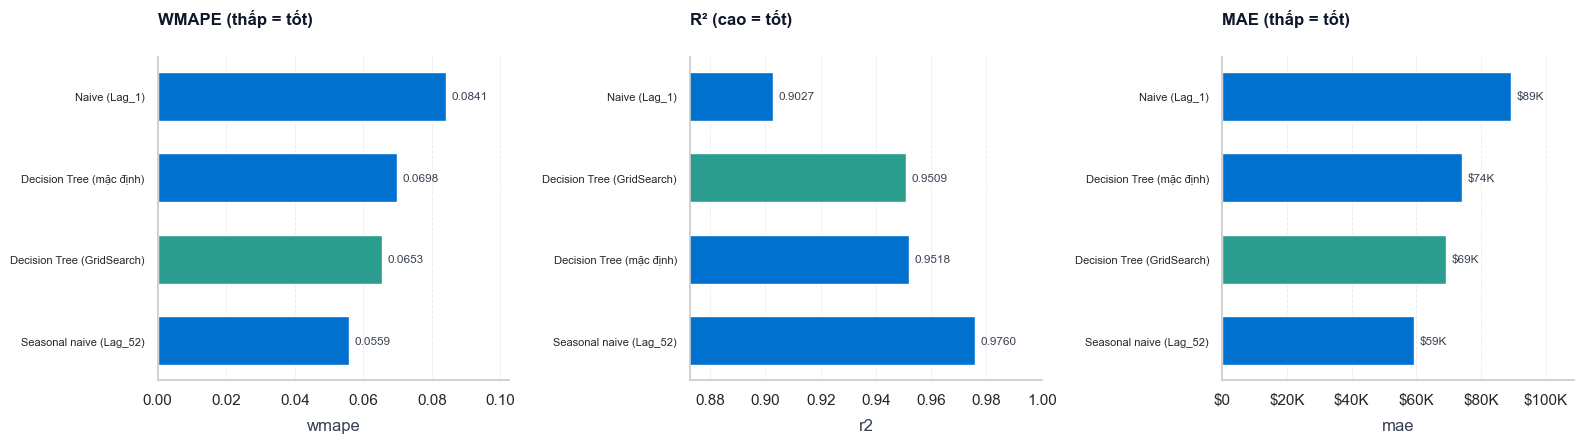

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))
specs = [("wmape", "WMAPE (thấp = tốt)", lambda v: f"{v:.4f}"),
         ("r2", "R² (cao = tốt)", lambda v: f"{v:.4f}"),
         ("mae", "MAE (thấp = tốt)", money)]

for ax, (metric, title, fmt) in zip(axes, specs):
    d = final_tbl[metric].sort_values(ascending=(metric != "r2"))
    cols = [THEME["success"] if "GridSearch" in i else THEME["blue"] for i in d.index]
    bars = ax.barh([i[:26] for i in d.index], d.values, color=cols, height=0.6)
    label_bars(ax, bars, fmt)
    if metric == "r2":
        # Mọi model đều 0.90-0.98; để trục từ 0 thì 4 thanh trông y hệt nhau.
        ax.set_xlim(float(d.min()) - 0.03, 1.0)
    else:
        ax.set_xlim(0, float(d.max()) * 1.22)
    if metric == "mae":
        ax.xaxis.set_major_formatter(MONEY_FMT)
    set_chart_title(ax, title)
    clean_axis(ax, metric, "", xgrid=True)
    ax.tick_params(axis="y", labelsize=8)

fig.tight_layout()
plt.show()

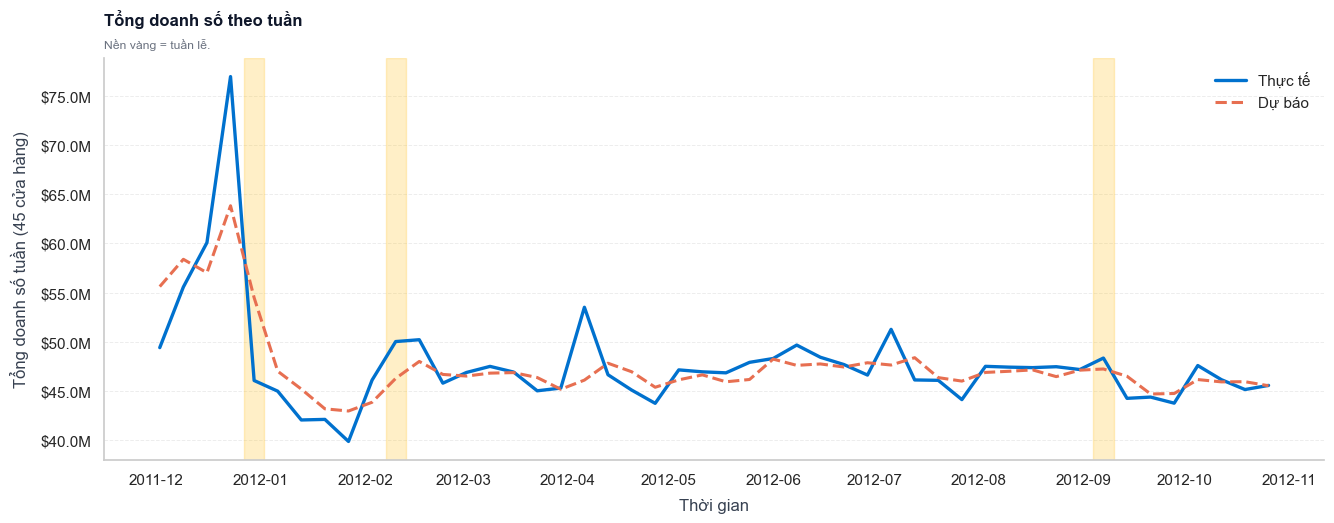

In [15]:
val_eval = val_set[["Store", "Date", "IsHoliday", "Weekly_Sales"]].copy()
val_eval["y_pred"] = pred_best
val_eval["residual"] = val_eval["Weekly_Sales"] - val_eval["y_pred"]

weekly = val_eval.groupby("Date", as_index=False).agg(
    y_true=("Weekly_Sales", "sum"), y_pred=("y_pred", "sum"),
    IsHoliday=("IsHoliday", "first"))

fig, ax = plt.subplots(figsize=(13.5, 5.4))
for _, r in weekly[weekly["IsHoliday"] == 1].iterrows():
    ax.axvspan(r["Date"] - pd.Timedelta(days=3), r["Date"] + pd.Timedelta(days=3),
               color=THEME["yellow"], alpha=0.25)
ax.plot(weekly["Date"], weekly["y_true"], lw=2.4, color=THEME["blue"], label="Thực tế")
ax.plot(weekly["Date"], weekly["y_pred"], lw=2.2, color=THEME["danger"], ls="--", label="Dự báo")
ax.yaxis.set_major_formatter(MONEY_FMT)
set_chart_title(ax, "Tổng doanh số theo tuần", "Nền vàng = tuần lễ.")
clean_axis(ax, "Thời gian", "Tổng doanh số tuần (45 cửa hàng)")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

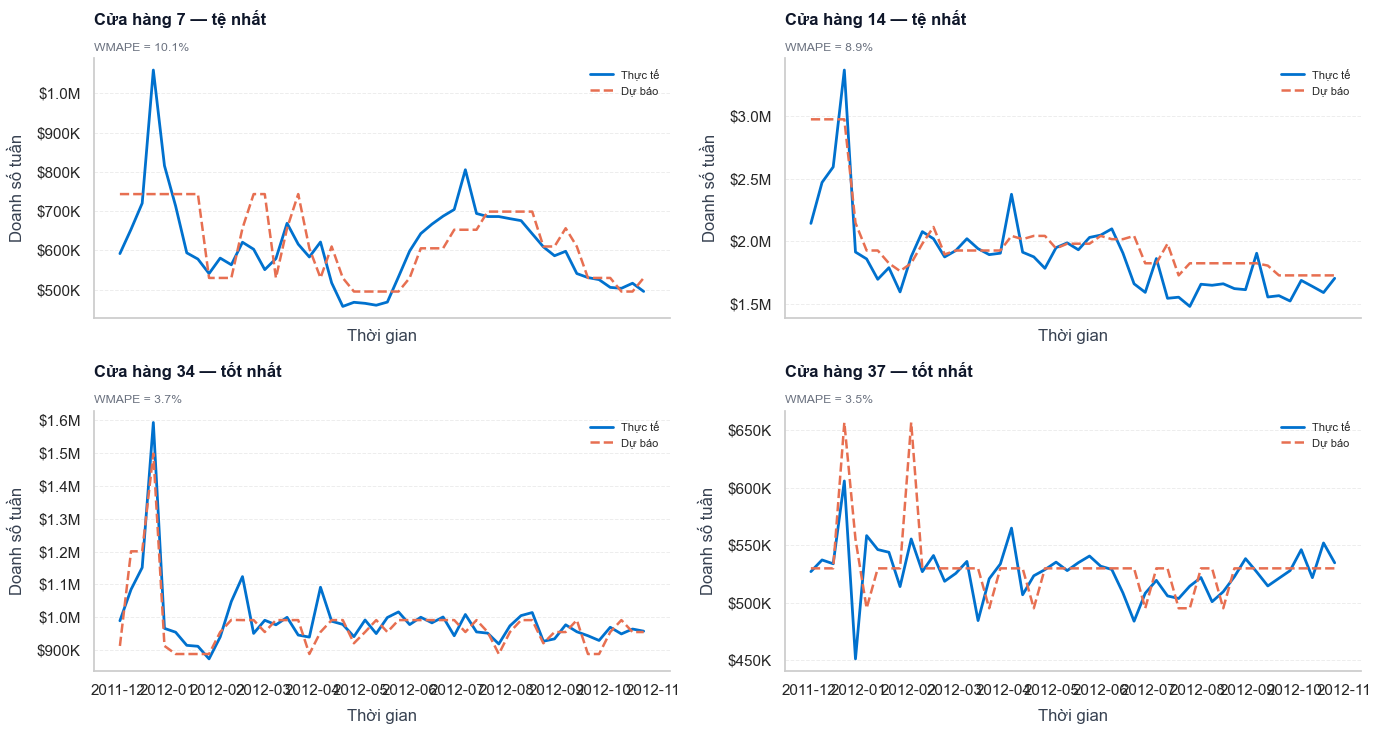

,Mean_Sales,MAE,WMAPE
Store,,,
7,$609K,61493.0,10.11%
14,$1.9M,165896.0,8.85%
15,$603K,53333.0,8.84%
16,$531K,46956.0,8.84%
22,$1.0M,89249.0,8.67%
29,$537K,46101.0,8.59%
18,$1.1M,91148.0,8.43%
28,$1.3M,107605.0,8.24%
35,$847K,69549.0,8.21%


In [18]:
store_err = (val_eval.groupby("Store")
             .apply(lambda g: pd.Series({
                 "Mean_Sales": g["Weekly_Sales"].mean(),
                 "MAE": np.abs(g["Weekly_Sales"] - g["y_pred"]).mean(),
                 "WMAPE": wmape(g["Weekly_Sales"], g["y_pred"]),
             }), include_groups=False)
             .sort_values("WMAPE", ascending=False))

worst, best = store_err.head(2).index.tolist(), store_err.tail(2).index.tolist()

fig, axes = plt.subplots(2, 2, figsize=(14, 7.5), sharex=True)
for ax, store in zip(axes.ravel(), worst + best):
    g = val_eval[val_eval["Store"] == store].sort_values("Date")
    ax.plot(g["Date"], g["Weekly_Sales"], lw=2, color=THEME["blue"], label="Thực tế")
    ax.plot(g["Date"], g["y_pred"], lw=1.8, ls="--", color=THEME["danger"], label="Dự báo")
    ax.yaxis.set_major_formatter(MONEY_FMT)
    set_chart_title(ax, f"Cửa hàng {store} — {'tệ nhất' if store in worst else 'tốt nhất'}",
                    f"WMAPE = {store_err.loc[store, 'WMAPE']:.1%}")
    clean_axis(ax, "Thời gian", "Doanh số tuần")
    ax.legend(frameon=False, fontsize=8)
fig.tight_layout()
plt.show()

show = store_err.head(10).copy()
show["Mean_Sales"] = show["Mean_Sales"].map(money)
show["MAE"] = show["MAE"].round(0)
show["WMAPE"] = (show["WMAPE"] * 100).round(2).astype(str) + "%"
show

## 6. Trực quan hoá mô hình

| | Cho biết |
|---|---|
| `plot_tree` | Cây chia theo ngưỡng nào, ở tầng nào |
| `feature_importances_` | Mức giảm sai số cộng dồn tại các nút. Không có dấu |
| SHAP | Tác động lên từng dòng, tính bằng đô la, có dấu ± |

`TreeExplainer` cộng dồn chính xác: `nền + tổng SHAP = dự báo`.

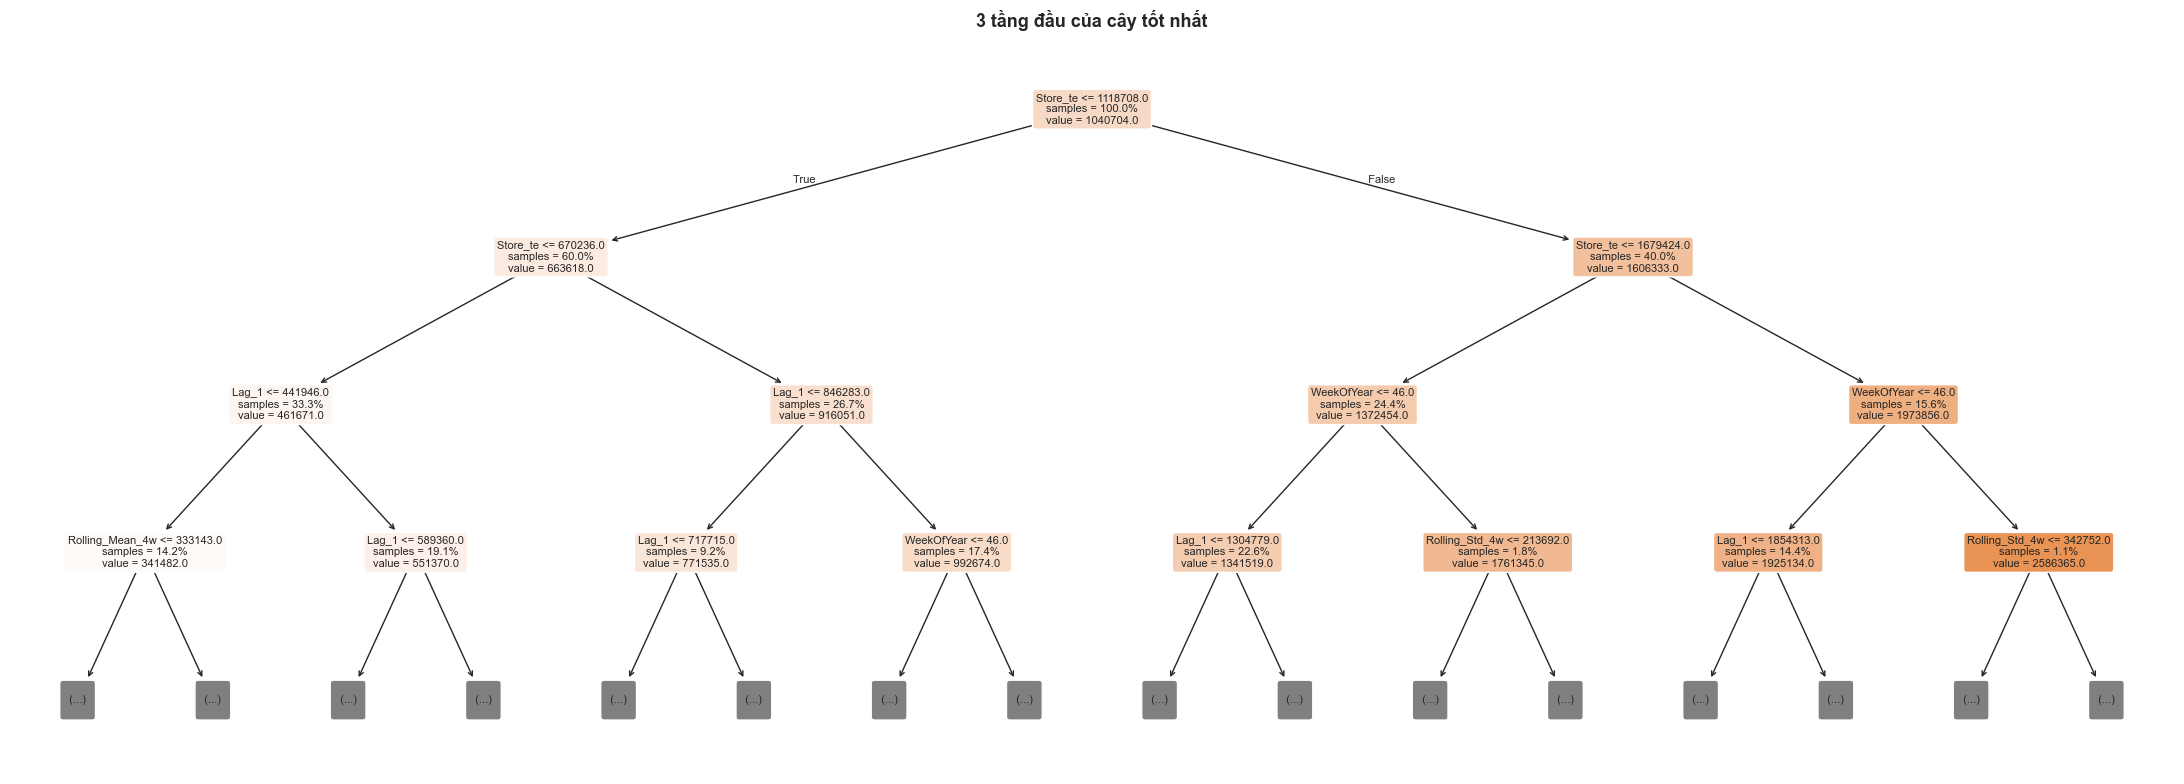

|--- Store_te <= 1118708
|   |--- Store_te <= 670236
|   |   |--- Lag_1 <= 441946
|   |   |   |--- truncated branch of depth 6
|   |   |--- Lag_1 >  441946
|   |   |   |--- truncated branch of depth 6
|   |--- Store_te >  670236
|   |   |--- Lag_1 <= 846283
|   |   |   |--- truncated branch of depth 6
|   |   |--- Lag_1 >  846283
|   |   |   |--- truncated branch of depth 6
|--- Store_te >  1118708
|   |--- Store_te <= 1679424
|   |   |--- WeekOfYear <= 46
|   |   |   |--- truncated branch of depth 6
|   |   |--- WeekOfYear >  46
|   |   |   |--- truncated branch of depth 3
|   |--- Store_te >  1679424
|   |   |--- WeekOfYear <= 46
|   |   |   |--- truncated branch of depth 6
|   |   |--- WeekOfYear >  46
|   |   |   |--- truncated branch of depth 2



In [19]:
fig, ax = plt.subplots(figsize=(22, 8))
plot_tree(best_dt, max_depth=3, feature_names=list(X_train.columns),
          filled=True, rounded=True, proportion=True, precision=0,
          fontsize=8, impurity=False, ax=ax)
ax.set_title("3 tầng đầu của cây tốt nhất", fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()

print(export_text(best_dt, feature_names=list(X_train.columns), max_depth=2, decimals=0))

Sai lệch cộng dồn: 0.000000
Giá trị nền: $1.0M


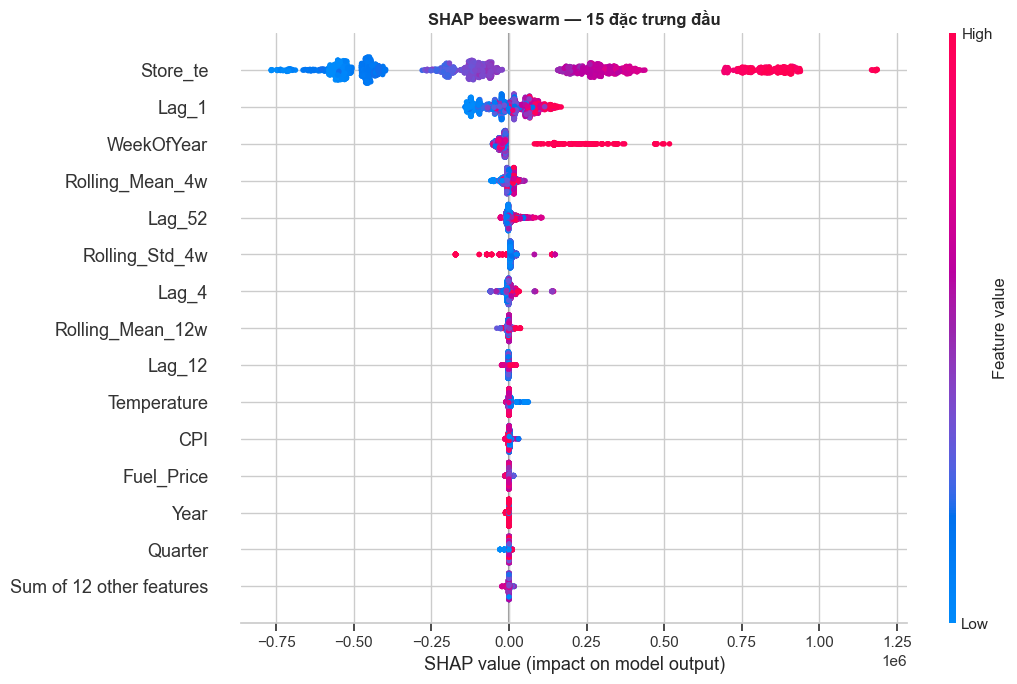

In [20]:
import shap

explainer = shap.TreeExplainer(best_dt)
shap_values = explainer(X_val)

sai_lech = np.abs(np.ravel(shap_values.base_values) + shap_values.values.sum(axis=1)
                  - pred_best).max()
print(f"Sai lệch cộng dồn: {sai_lech:.6f}")
print(f"Giá trị nền: {money(float(np.ravel(shap_values.base_values)[0]))}")

plt.figure()
shap.plots.beeswarm(shap_values, max_display=15, show=False)
plt.title("SHAP beeswarm — 15 đặc trưng đầu", fontsize=12, fontweight="bold")
plt.gcf().set_size_inches(11, 7)
plt.tight_layout()
plt.show()

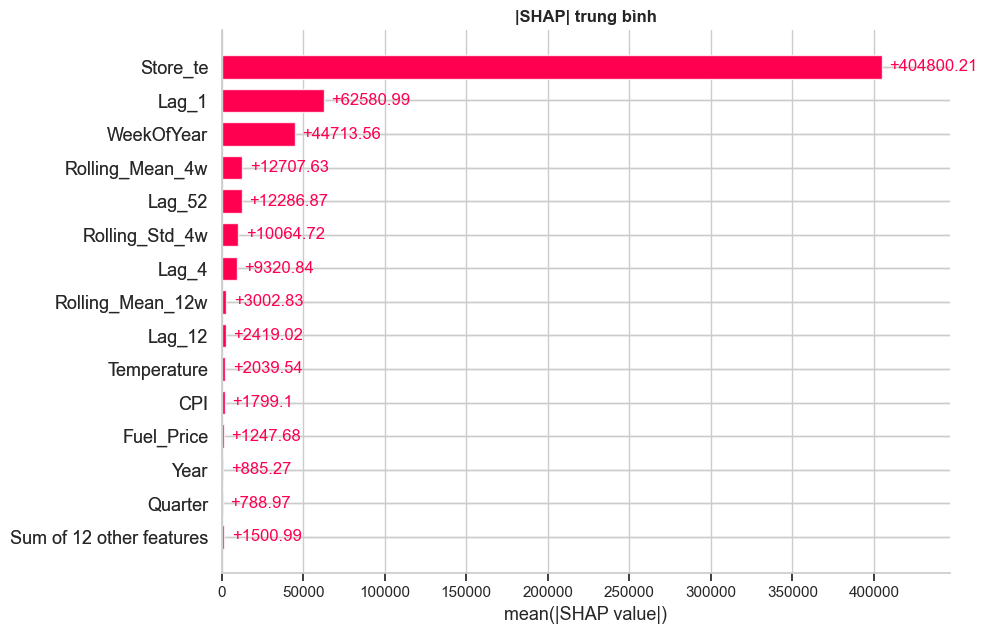

In [21]:
plt.figure()
shap.plots.bar(shap_values, max_display=15, show=False)
plt.title("|SHAP| trung bình", fontsize=12, fontweight="bold")
plt.gcf().set_size_inches(10, 6.5)
plt.tight_layout()
plt.show()